In [1]:
import pyodbc
import pandas as pd
import numpy as np

cnxn = pyodbc.connect('DSN=Hermes_DSN',autocommit=True)
cursor = cnxn.cursor()

# Prep

In [2]:
#hedge_funds = pd.read_csv('sftds_hedgefunds.csv')

In [3]:
#hf_unique = tuple(hedge_funds['0'].unique())

In [4]:
#isin = pd.read_excel('EA_ISINs.xlsx')

In [5]:
#unique_isin = tuple(isin['ISIN'])

# Monetary policy shocks

In [6]:
df = pd.read_csv('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\bond_timeseries_v2.csv')

In [7]:
df['ISIN'].str[:2].unique()

array(['DE', 'ES', 'FR', 'IT', 'AT', 'BE', 'FI', 'GR', 'IE', 'LU', 'NL',
       'PT', 'SI', 'SK'], dtype=object)

In [8]:
df['Dates'] = pd.to_datetime(df['Dates'])
df['bond_maturity'] = pd.to_datetime(df['bond_maturity'])

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\996206371.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['bond_maturity'] = pd.to_datetime(df['bond_maturity'])


In [9]:
# calculate residual maturity in years
df['residual_bond_maturity'] = ((df['bond_maturity'] - df['Dates']).dt.days / 365)

In [10]:
df = df[df['residual_bond_maturity'] >= 0]

In [11]:
df['amt_issued'] = (
    df['amt_issued']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
)

# convert to float, coercing invalid entries to NaN
df['amt_issued'] = pd.to_numeric(df['amt_issued'], errors='coerce')
df['amt_issued'] = df['amt_issued']/1e9

In [12]:
df['amt_issued'].fillna(df['amt_issued'].median(), inplace=True)

In [13]:
df['collateral_country'] = df['ISIN'].str[:2]

In [14]:
df = df[df['collateral_country'].isin(['DE','IT'])]

In [15]:
securities = tuple(df['ISIN'].unique())

In [16]:
len(securities)

763

In [17]:
len(df)

732272

In [18]:
# Data prep
query = f""" 

SELECT DISTINCT lender_id

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
""" 

df_hf = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\3955607767.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hf = pd.read_sql_query(query, cnxn)


In [19]:
# Data prep
query = f""" 

SELECT DISTINCT borrower_id

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
""" 

df_hf_b = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\1803038206.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_hf_b = pd.read_sql_query(query, cnxn)


In [20]:
len(pd.concat([df_hf_b['borrower_id'], df_hf['lender_id']]).unique())

152

In [21]:
# Data prep
query = f""" 

SELECT s.business_date, 
security_isin as isin,
sum(nominal_euro) as borrowing_volume,
avg(contractual_maturity) as long_maturity,
avg(haircut) as long_haircut

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
--AND contractual_maturity > 1
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\1947693829.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [22]:
# Data prep
query = f""" 
 

SELECT s.business_date,
security_isin as isin,
sum(nominal_euro) as lending_volume,
avg(contractual_maturity) as short_maturity,
avg(haircut) as short_haircut

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
--AND contractual_maturity > 1
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\1851674468.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [23]:
df_repo = df_borrowing.merge( df_lending, on=['business_date', 'isin'], how='outer', suffixes=('_borrowing', '_lending') )
 

In [24]:
df_repo['business_date'] = pd.to_datetime(df_repo['business_date'])

In [25]:
df = (
    df[['Dates', 'ISIN', 'PX_ASK', 'PX_BID', 'YLD_YTM_ASK', 'YLD_YTM_BID', 'amt_issued', 'residual_bond_maturity', 'collateral_country']]
    .merge(df_repo, right_on=['business_date','isin'], left_on = ['Dates', 'ISIN'], how='left')
)

In [26]:
df = df[df['PX_ASK'].isna() == False]

In [27]:
df.drop(columns=['business_date', 'isin'], inplace=True)

In [28]:
df = df.rename(columns={'Dates': 'business_date'})
df = df.rename(columns={'ISIN': 'isin'})

In [29]:
df['borrowing_volume'].fillna(0, inplace = True)
df['lending_volume'].fillna(0, inplace = True)

In [30]:
df['net_pos'] = (df['borrowing_volume'] - df['lending_volume'])/1e9

In [31]:
df.head()

,business_date,isin,PX_ASK,PX_BID,YLD_YTM_ASK,YLD_YTM_BID,amt_issued,residual_bond_maturity,collateral_country,borrowing_volume,long_maturity,long_haircut,lending_volume,short_maturity,short_haircut,net_pos
0,2021-01-01,DE0001030203,100.225,100.200,-0.816,-0.726,18.0,0.282192,DE,0.0,NaN,NaN,0.0,NaN,NaN,0.0
1,2021-01-01,DE0001030229,100.343,100.315,-0.794,-0.729,19.5,0.435616,DE,0.0,NaN,NaN,0.0,NaN,NaN,0.0
2,2021-01-01,DE0001030294,100.046,100.039,-1.103,-0.936,13.5,0.052055,DE,0.0,NaN,NaN,0.0,NaN,NaN,0.0
3,2021-01-01,DE0001030310,100.075,100.068,-0.930,-0.844,13.5,0.090411,DE,0.0,NaN,NaN,0.0,NaN,NaN,0.0
5,2021-01-01,DE0001104750,100.193,100.094,-1.065,-0.519,13.0,0.191781,DE,0.0,NaN,NaN,0.0,NaN,NaN,0.0


In [32]:
len(df)

485236

In [33]:
shocks_all = pd.read_excel('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\altavilla.xlsx', sheet_name = 'Monetary Event Window')

In [34]:
shocks_all['date'] = pd.to_datetime(shocks_all['date'], dayfirst=True)

In [35]:
out = (
    df.merge(shocks_all[['date', 'OIS_2Y']], left_on=['business_date'], right_on=['date'], how='left')
       .drop(columns=['date'])  # helpers
)


In [36]:
out['OIS_2Y'].fillna(0, inplace=True)

In [37]:
out = out.sort_values(['isin','business_date'])

# mid yield
out['yld_mid'] = (out['YLD_YTM_BID'] + out['YLD_YTM_ASK']) / 2

# ISIN-level daily change
out['delta_y'] = out.groupby('isin')['yld_mid'].diff()

In [38]:
# 1. Base Intensity: Rolling mean of |net_pos| (Magnitude only)
out['abs_net'] = (out['net_pos'].abs() / out['amt_issued']) * 100

In [39]:
hf_roll = (
    out.groupby('isin')['abs_net']
     .apply(lambda s: s.rolling(window=5, min_periods=3).mean().shift(1))
     .reset_index(level=0, drop=True)   # <-- align index with d
)

out['hf_intensity_pre'] = hf_roll

In [40]:
out['net_pos_scaled'] = (out['net_pos'] / out['amt_issued']) * 100

hf_roll_signed = (
    out.groupby('isin')['net_pos_scaled']
     .apply(lambda s: s.rolling(window=5, min_periods=3).mean().shift(1))
     .reset_index(level=0, drop=True)
)

out['hf_intensity_long'] = np.where(hf_roll_signed > 0, out['hf_intensity_pre'], 0)
out['hf_intensity_short'] = np.where(hf_roll_signed < 0, out['hf_intensity_pre'], 0)

In [41]:
out['hf_intensity_pre']= out['hf_intensity_pre'].fillna(0)

In [42]:
out['bid_ask_spread'] = out['PX_ASK'] - out['PX_BID'] 

In [43]:
out['delta_y'] = out['delta_y']*100

In [44]:
ctd = pd.read_excel('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\CTD.xlsx')

In [45]:
# month-end of (Year, Month)
ctd['period_end'] = pd.to_datetime(dict(year=ctd['Year'], month=ctd['Month'], day=1)) + pd.offsets.MonthEnd(0)
ctd['period_start'] = ctd['period_end'] - pd.DateOffset(years=1)

In [46]:
# --- expand & mark in-window ---
m = out.merge(ctd[['isin','period_start','period_end']], on='isin', how='left')
m['in_window'] = (m['business_date'] >= m['period_start']) & (m['business_date'] <= m['period_end'])

# collapse back to one row per (ISIN, business_date): 1 if any window matches
flag_df = (m.groupby(['isin','business_date'], as_index=False)['in_window']
             .any()
             .rename(columns={'in_window':'ctd_flag'}))

# --- attach flag to original `out` ---
out = out.merge(flag_df, on=['isin','business_date'], how='left')
out['ctd_flag'] = out['ctd_flag'].fillna(False).astype(int)


In [47]:
len(out)

485236

In [48]:
# create binary
out.loc[(out['hf_intensity_pre'] > 0), 'hf_involved'] = 1
out['hf_involved'].fillna(0, inplace = True)

In [49]:
out['prev_net_pos'] = out.groupby('isin')['net_pos'].shift(1)

In [50]:
# create binary
out.loc[(out['prev_net_pos'] > 0), 'hf_involved_long'] = 1
out['hf_involved_long'].fillna(0, inplace = True)

out.loc[(out['prev_net_pos'] < 0), 'hf_involved_short'] = 1
out['hf_involved_short'].fillna(0, inplace = True)

In [51]:
out['hf_intensity_pre'][out['hf_intensity_pre'] > 0].quantile(0.99)

18.033837569200852

In [52]:
out['hf_intensity_pre'][out['hf_intensity_pre'] > 0].quantile(0.01)

0.020282621276595744

In [53]:
out = out[out['hf_intensity_pre'] < 18]

In [54]:
# Four categories: None / Low / Medium / High
out['hf_category'] = 'ANone'

# Identify ISIN–days with positive HF activity
mask = out['hf_intensity_pre'].fillna(0) > 0

# Within each country, split only those into terciles
out.loc[mask, 'hf_category'] = (
    out.loc[mask]
       .groupby('collateral_country')['hf_intensity_pre']
       .transform(lambda x: pd.qcut(x, 2, labels=['Low', 'High']))
       .astype(str)
)

In [55]:
# Four categories: None / Low / Medium / High
out['hf_category_ext'] = 'ANone'

# Identify ISIN–days with positive HF activity
mask = out['hf_intensity_pre'].fillna(0) > 0

# Within each country, split only those into terciles
out.loc[mask, 'hf_category_ext'] = (
    out.loc[mask]
       .groupby('collateral_country')['hf_intensity_pre']
       .transform(lambda x: pd.qcut(x, 3, labels=['Low', 'Medium', 'High']))
       .astype(str)
)

In [56]:
len(out)

482647

In [57]:
out = out[out['delta_y'].isna() == False]

In [58]:
len(out)

479403

In [59]:
out['delta_y'].quantile(0.999)

37.8098000000056

In [60]:
out['delta_y'].quantile(0.001)

-40.30980000000001

In [61]:
out = out[(out['delta_y'] <= 40) & (out['delta_y'] >= -40)]

In [62]:
out['delta_y'].describe()

count    478483.000000
mean          0.155552
std           5.788644
min         -39.950000
25%          -2.250000
50%           0.000000
75%           2.750000
max          40.000000
Name: delta_y, dtype: float64

In [63]:
len(out)

478483

In [64]:
germany = pd.read_csv('NelsonSiegel_DE_prices.csv')

In [65]:
italy = pd.read_csv('NelsonSiegel_IT_prices.csv')

In [66]:
spain = pd.read_csv('NelsonSiegel_ES_prices.csv')

In [67]:
france = pd.read_csv('NelsonSiegel_FR_prices.csv')

In [68]:
df_duration = pd.concat([germany, italy], ignore_index=True)

In [69]:
df_duration['refdate'] = pd.to_datetime(df_duration['refdate'])

In [70]:
out = out.merge(df_duration[['refdate', 'bondcode', 'duration']], left_on = ['business_date', 'isin'], right_on = ['refdate', 'bondcode'], how = 'left')

In [71]:
len(out)

478483

In [72]:
out['duration'].fillna(out['residual_bond_maturity'], inplace = True)

In [73]:
len(out[out['duration'].isna()])/len(out)

0.0

In [74]:
summary = out.groupby('hf_category').agg({
    'isin': 'count',
    'collateral_country': lambda x: (x == 'IT').mean(),
    'amt_issued': 'mean',
    'residual_bond_maturity': 'mean',
    'bid_ask_spread': 'mean',
    'ctd_flag': 'mean'
})

print(summary)

               isin  collateral_country  amt_issued  residual_bond_maturity  \
hf_category                                                                   
ANone        224508            0.626071   10.480025                7.858231   
High         126892            0.627723   20.497740                6.551100   
Low          127083            0.628298   19.107123                9.154039   

             bid_ask_spread  ctd_flag  
hf_category                            
ANone              0.548557  0.000539  
High               0.067454  0.092591  
Low                0.116396  0.029595  


In [75]:
jk_shock = pd.read_csv('C:\\Users\\hermesf\\Projects\\JobMarket\\Data\\shocks_ecb_mpd_me_d.csv')

In [76]:
jk_shock['business_date'] = pd.to_datetime(jk_shock['date'])

In [77]:
jk_shock.head()

,date,pc1,STOXX50,MP_pm,CBI_pm,MP_median,CBI_median,business_date
0,1999-01-07,-0.037546,-1.231443,-0.000000,-0.037546,0.020578,-0.058123,1999-01-07
1,1999-01-21,0.003581,-0.212126,0.003581,0.000000,0.008569,-0.004988,1999-01-21
2,1999-02-18,-0.000000,0.174157,-0.000000,-0.000000,-0.005565,0.005565,1999-02-18
3,1999-03-04,-0.001926,0.082407,-0.001926,-0.000000,-0.003596,0.001670,1999-03-04
4,1999-03-18,-0.000758,0.060922,-0.000758,-0.000000,-0.002326,0.001568,1999-03-18


In [78]:
out = out.merge(jk_shock, on = 'business_date', how = 'left')

In [79]:
# Option 1: reassign
out[['pc1', 'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median']] = out[['pc1', 'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median']].fillna(0)

In [80]:
out[['pc1', 'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median']] = out[['pc1', 'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median']] * 100

In [81]:
out['hf_intensity_pre'].describe()

count    478483.000000
mean          1.591826
std           2.809005
min           0.000000
25%           0.000000
50%           0.146401
75%           1.977853
max          17.998381
Name: hf_intensity_pre, dtype: float64

In [82]:
# 1. Calculate the daily change in position (Flow)
out['daily_net_change'] = out.groupby('isin')['net_pos'].diff()
out['delta_intensity'] = (out['daily_net_change'] / out['amt_issued']) * 100

In [83]:
# 3. Determine the Direction ENTERING the shock (State) - Keep this as is
out['is_long_pre'] = (out.groupby('isin')['net_pos'].shift(1) > 0).astype(int)
out['is_short_pre'] = (out.groupby('isin')['net_pos'].shift(1) < 0).astype(int)

In [84]:
out['placebo_shock'] = out.groupby('isin')['OIS_2Y'].shift(15)
out['placebo_shock'].fillna(0, inplace=True)

In [85]:
# Data prep: fund-level LONG positions (HF is the borrower -> long the bond)
query = f""" 

SELECT s.business_date, 
security_isin as isin,
borrower_id as fund_id,
sum(nominal_euro) as long_vol

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
GROUP BY business_date, isin, borrower_id
ORDER BY business_date, isin 

""" 

df_long_fund = pd.read_sql_query(query, cnxn)
df_long_fund['business_date'] = pd.to_datetime(df_long_fund['business_date'])

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\85804849.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_long_fund = pd.read_sql_query(query, cnxn)


In [86]:
# Data prep: fund-level SHORT positions (HF is the lender -> short the bond)
query = f""" 

SELECT s.business_date,
security_isin as isin,
lender_id as fund_id,
sum(nominal_euro) as short_vol

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND gnlcoll = 'SPEC'
AND security_isin IN {securities}
GROUP BY business_date, isin, lender_id
ORDER BY business_date, isin 

""" 

df_short_fund = pd.read_sql_query(query, cnxn)
df_short_fund['business_date'] = pd.to_datetime(df_short_fund['business_date'])

C:\Users\hermesf\AppData\Local\Temp\ipykernel_15048\3305751002.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_short_fund = pd.read_sql_query(query, cnxn)


In [87]:
# --- Fund-level directionality (duration-weighted) -> holder-weighted bond measure ---

# 1. One row per fund-bond-day with signed net (long +, short -)
fb = df_long_fund.merge(df_short_fund, on=['business_date','isin','fund_id'], how='outer')
fb[['long_vol','short_vol']] = fb[['long_vol','short_vol']].fillna(0)
fb['net']    = fb['long_vol'] - fb['short_vol']
fb['absnet'] = fb['net'].abs()

# 2. fund_dir per fund-day: DV01 (duration-weighted) directionality across ALL bonds
#    |sum net*dur| / sum|net*dur|.  0 = duration-hedged (carry or curve), 1 = directional.
fb = fb.merge(df_duration[['refdate','bondcode','duration']],
              left_on=['business_date','isin'], right_on=['refdate','bondcode'], how='left')
fb = fb.drop(columns=['refdate','bondcode'])
fb['dv01']    = fb['net'] * fb['duration']
fb['absdv01'] = fb['dv01'].abs()
fd = fb.groupby(['business_date','fund_id']).agg(
    net_dv01  =('dv01','sum'),
    gross_dv01=('absdv01','sum'),
).reset_index()
fd['fund_dir'] = fd['net_dv01'].abs() / fd['gross_dv01'].where(fd['gross_dv01'] > 0)
fund_dir = fd[['business_date','fund_id','fund_dir']]

# 3. holder_dir per bond-day: |net|-weighted average of holders' fund_dir.
#    Funds with undefined fund_dir (no duration) drop out of both num and den.
fb = fb.merge(fund_dir, on=['business_date','fund_id'], how='left')
fb['w_num']   = fb['absnet'] * fb['fund_dir']
fb['w_den']   = fb['absnet'].where(fb['fund_dir'].notna(), 0.0)
fb['islong']  = fb['long_vol']  > 0
fb['isshort'] = fb['short_vol'] > 0
holder = fb.groupby(['business_date','isin']).agg(
    holder_num =('w_num','sum'),
    holder_den =('w_den','sum'),
    gross_long =('long_vol','sum'),
    gross_short=('short_vol','sum'),
    n_long     =('islong','sum'),
    n_short    =('isshort','sum'),
).reset_index()
# safe divide: den<=0 becomes NaN so holder_dir is NaN there (stays float)
holder['holder_dir'] = holder['holder_num'] / holder['holder_den'].where(holder['holder_den'] > 0)
holder = holder.drop(columns=['holder_num','holder_den'])

# 4. merge onto out (holder_dir stays NaN where no HF holds the bond = zero-intensity baseline)
out = out.merge(holder, on=['business_date','isin'], how='left')


In [88]:
out.sample(5)

,business_date,isin,PX_ASK,PX_BID,YLD_YTM_ASK,YLD_YTM_BID,amt_issued,residual_bond_maturity,collateral_country,borrowing_volume,...,daily_net_change,delta_intensity,is_long_pre,is_short_pre,placebo_shock,gross_long,gross_short,n_long,n_short,holder_dir
286936,2025-05-14,IT0004976624,75.989,75.135,3.366,3.507,10.520099,8.306849,IT,0.000000e+00,...,0.000000,0.000000,0,0,0.0,NaN,NaN,NaN,NaN,NaN
249803,2022-03-28,IT0004735152,123.504,123.410,-1.913,-1.896,12.570000,4.471233,IT,7.946086e+07,...,0.000000,0.000000,0,1,0.0,7.946086e+07,1.779832e+08,2.0,1.0,0.509824
118537,2024-05-24,DE0001142651,82.807,82.187,2.512,2.613,10.520099,7.619178,DE,0.000000e+00,...,0.000000,0.000000,0,0,0.0,NaN,NaN,NaN,NaN,NaN
325962,2025-08-06,IT0005177909,88.697,88.657,3.520,3.525,17.178000,11.079452,IT,1.012984e+08,...,0.086301,0.502392,0,1,0.0,1.012984e+08,1.516282e+09,1.0,17.0,0.120778
155484,2021-10-12,DE0004123500,115.921,115.209,-0.547,-0.263,1.853380,2.246575,DE,0.000000e+00,...,0.000000,0.000000,0,0,0.0,NaN,NaN,NaN,NaN,NaN


In [89]:
out.columns

Index(['business_date', 'isin', 'PX_ASK', 'PX_BID', 'YLD_YTM_ASK',
       'YLD_YTM_BID', 'amt_issued', 'residual_bond_maturity',
       'collateral_country', 'borrowing_volume', 'long_maturity',
       'long_haircut', 'lending_volume', 'short_maturity', 'short_haircut',
       'net_pos', 'OIS_2Y', 'yld_mid', 'delta_y', 'abs_net',
       'hf_intensity_pre', 'net_pos_scaled', 'hf_intensity_long',
       'hf_intensity_short', 'bid_ask_spread', 'ctd_flag', 'hf_involved',
       'prev_net_pos', 'hf_involved_long', 'hf_involved_short', 'hf_category',
       'hf_category_ext', 'refdate', 'bondcode', 'duration', 'date', 'pc1',
       'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'daily_net_change', 'delta_intensity', 'is_long_pre', 'is_short_pre',
       'placebo_shock', 'gross_long', 'gross_short', 'n_long', 'n_short',
       'holder_dir'],
      dtype='object')

In [90]:
out = out[['business_date', 'isin', 'PX_ASK', 'PX_BID', 'YLD_YTM_ASK',
       'YLD_YTM_BID', 'amt_issued', 'residual_bond_maturity',
       'collateral_country', 'borrowing_volume', 'long_maturity',
       'long_haircut', 'lending_volume', 'short_maturity', 'short_haircut',
       'net_pos', 'OIS_2Y', 'yld_mid', 'delta_y', 'abs_net',
       'hf_intensity_pre', 'net_pos_scaled', 'hf_intensity_long',
       'hf_intensity_short', 'bid_ask_spread', 'ctd_flag', 'hf_involved',
       'prev_net_pos', 'hf_involved_long', 'hf_involved_short', 'hf_category',
       'hf_category_ext', 'refdate', 'duration', 'date', 'pc1',
       'STOXX50', 'MP_pm', 'CBI_pm', 'MP_median', 'CBI_median',
       'daily_net_change', 'delta_intensity', 'is_long_pre', 'is_short_pre',
       'placebo_shock', 'gross_long', 'n_long', 'gross_short', 'n_short', 'holder_dir']]

In [91]:
#out['isin'] = out['isin'].factorize()[0]

In [92]:
out.to_csv('monetary_policy_induced_position.csv')

# Descriptives

In [85]:
out['delta_y'].describe()

count    478483.000000
mean          0.155552
std           5.788644
min         -39.950000
25%          -2.250000
50%           0.000000
75%           2.750000
max          40.000000
Name: delta_y, dtype: float64

In [87]:
out['delta_y'][out['OIS_2Y'] == 0].describe()

count    463914.000000
mean          0.126890
std           5.616459
min         -39.950000
25%          -2.250000
50%           0.000000
75%           2.700000
max          40.000000
Name: delta_y, dtype: float64

In [82]:
out['duration'].describe()

count    4.770010e+05
mean     7.130542e+00
std      7.002362e+00
min     -5.887524e-12
25%      1.773637e+00
50%      5.136986e+00
75%      1.046575e+01
max      4.754247e+01
Name: duration, dtype: float64

In [83]:
out['bid_ask_spread'].describe()

count    477001.000000
mean          0.306380
std           0.417546
min          -0.127000
25%           0.034000
50%           0.108000
75%           0.441000
max           3.881000
Name: bid_ask_spread, dtype: float64

In [84]:
out['amt_issued'].describe()

count    477001.000000
mean         15.431768
std           7.359619
min           0.125000
25%          10.520099
50%          11.994517
75%          19.869551
max          44.500000
Name: amt_issued, dtype: float64

In [85]:
out['ctd_flag'].describe()

count    477001.000000
mean          0.032585
std           0.177548
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: ctd_flag, dtype: float64

In [86]:
out['hf_involved'].describe()

count    477001.000000
mean          0.532441
std           0.498947
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: hf_involved, dtype: float64

In [156]:
out['hf_intensity_pre'].describe()

count    477001.000000
mean          1.598233
std           2.828088
min           0.000000
25%           0.000000
50%           0.146014
75%           1.985058
max          24.778864
Name: hf_intensity_pre, dtype: float64

In [151]:
out['hf_intensity_long'].describe()

count    477001.000000
mean          0.724906
std           2.203634
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          24.778864
Name: hf_intensity_long, dtype: float64

In [152]:
out['hf_intensity_short'].describe()

count    477001.000000
mean          0.873328
std           2.099581
min           0.000000
25%           0.000000
50%           0.000000
75%           0.388923
max          21.119221
Name: hf_intensity_short, dtype: float64

In [155]:
round(out['hf_intensity_pre'][out['hf_intensity_pre'] != 0].describe(),2)

count    253111.00
mean          3.01
std           3.29
min           0.00
25%           0.64
50%           1.80
75%           4.26
max          24.78
Name: hf_intensity_pre, dtype: float64

In [153]:
round(out['hf_intensity_long'][out['hf_intensity_long'] != 0].describe(),2)

count    114473.00
mean          3.02
std           3.65
min           0.00
25%           0.54
50%           1.53
75%           4.05
max          24.78
Name: hf_intensity_long, dtype: float64

In [154]:
round(out['hf_intensity_short'][out['hf_intensity_short'] != 0].describe(),2)

count    138638.00
mean          3.00
std           2.96
min           0.00
25%           0.74
50%           2.00
75%           4.37
max          21.12
Name: hf_intensity_short, dtype: float64

In [93]:
round(out['long_haircut'][out['hf_intensity_long'] != 0].describe(),2)

count    109068.00
mean          0.24
std           0.54
min          -1.55
25%           0.00
50%           0.12
75%           0.30
max           4.76
Name: long_haircut, dtype: float64

In [94]:
out['delta_y'][out['OIS_2Y'] == 0].abs().mean()

3.725474741708508

In [95]:
round(out['short_haircut'][out['hf_intensity_short'] != 0].describe(),2)

count    133503.00
mean         -0.08
std           0.21
min          -2.65
25%          -0.15
50%          -0.05
75%           0.00
max           3.85
Name: short_haircut, dtype: float64

In [96]:
round(out['long_maturity'][out['hf_intensity_long'] != 0].describe(),2)

count    101535.00
mean         16.49
std          16.42
min           0.00
25%           7.50
50%          11.00
75%          18.65
max         279.00
Name: long_maturity, dtype: float64

In [97]:
round(out['short_maturity'][out['hf_intensity_short'] != 0].describe(),2)

count    127962.00
mean         18.50
std          19.25
min           0.00
25%           8.67
50%          13.17
75%          21.93
max         279.00
Name: short_maturity, dtype: float64

In [98]:
round(out['OIS_2Y'][(out['OIS_2Y'] != 0)].describe(),2)

count    14539.00
mean        -0.21
std          6.55
min        -19.50
25%         -3.35
50%         -0.30
75%          4.10
max         18.45
Name: OIS_2Y, dtype: float64

In [99]:
round(out['OIS_2Y'][(out['OIS_2Y'] > 0)].describe(),2)

count    5736.00
mean        5.87
std         4.10
min         0.36
25%         3.30
50%         4.95
75%         7.60
max        18.45
Name: OIS_2Y, dtype: float64

In [100]:
round(out['OIS_2Y'][(out['OIS_2Y'] < 0)].describe(),2)

count    8803.00
mean       -4.17
std         4.48
min       -19.50
25%        -6.72
50%        -3.13
75%        -0.56
max        -0.16
Name: OIS_2Y, dtype: float64

In [101]:
out['OIS_2Y'][out['OIS_2Y'] < 0].describe()

count    8803.000000
mean       -4.174486
std         4.480430
min       -19.500017
25%        -6.720001
50%        -3.129995
75%        -0.560001
max        -0.160000
Name: OIS_2Y, dtype: float64

In [102]:
out['OIS_2Y'][out['OIS_2Y'] > 0].describe()

count    5736.000000
mean        5.868616
std         4.103202
min         0.360000
25%         3.299999
50%         4.949999
75%         7.600000
max        18.449998
Name: OIS_2Y, dtype: float64

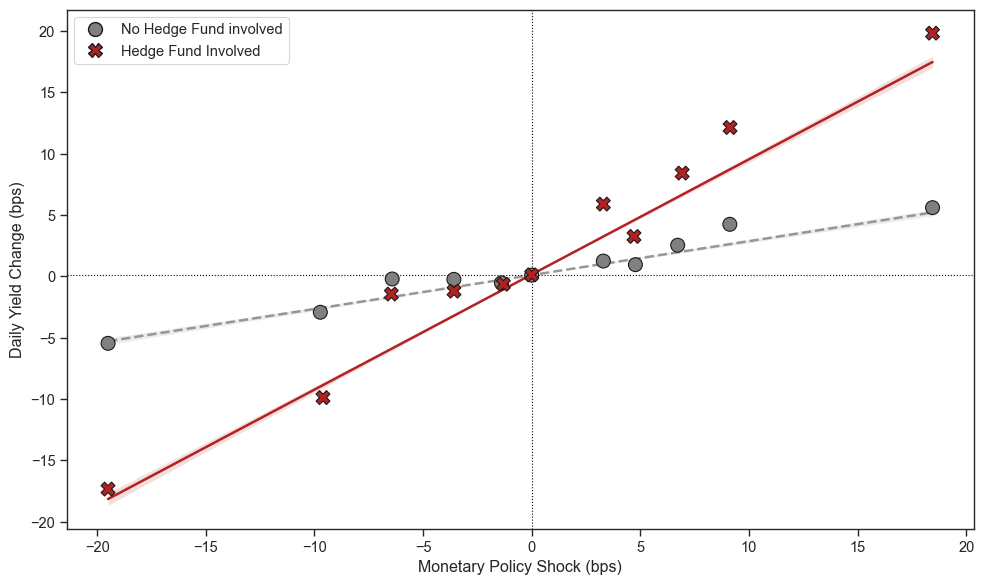

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Clean Data
plot_data = out.copy()



# 2. Residualize Y
plot_data['delta_y_resid'] = (
    plot_data['delta_y'] - 
    plot_data.groupby('isin')['delta_y'].transform('mean')
)
plot_data['delta_y_resid'] += plot_data['delta_y'].mean()

# ---------------------------------------------------------
# 3. WINSORIZE (The Fix for Asymmetry)
low_cut = plot_data['OIS_2Y'][plot_data['OIS_2Y'] != 0].quantile(0.02)
high_cut = plot_data['OIS_2Y'][plot_data['OIS_2Y'] != 0].quantile(0.98)
plot_data = plot_data[(plot_data['OIS_2Y'] >= low_cut) & (plot_data['OIS_2Y'] <= high_cut)]

# Replace the winsorize step with clipping
#plot_data['OIS_2Y'] = plot_data['OIS_2Y'].clip(-18, 18)

# 4. Create Bins (Uniform width)
plot_data['bin'] = pd.cut(plot_data['OIS_2Y'], bins=18)
# ---------------------------------------------------------

# 5. Aggregate
binned_means = (plot_data.groupby(['hf_involved', 'bin'], observed=True)
                .agg({'OIS_2Y': 'mean', 'delta_y_resid': 'mean', 'delta_y': 'count'})
                .rename(columns={'delta_y': 'obs_count'})
                .reset_index())

# Filter for robustness (minimum 10 obs per dot)
#binned_means = binned_means[binned_means['obs_count'] > 10]

# 6. ENFORCE COMMON SUPPORT
# Drop bins where we don't have BOTH groups to compare
valid_bins = binned_means.groupby('bin', observed=True)['hf_involved'].nunique()
bins_with_both = valid_bins[valid_bins == 2].index
binned_means = binned_means[binned_means['bin'].isin(bins_with_both)]

# 7. Plot
sns.set_theme(style="ticks", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# A. Regression Lines (using the WINSORIZED raw data)
sns.regplot(
    data=plot_data[plot_data['hf_involved']==0], 
    x='OIS_2Y', y='delta_y_resid', 
    scatter=False, color='gray', line_kws={'linestyle': '--', 'alpha': 0.8}, label='_nolegend_'
)
sns.regplot(
    data=plot_data[plot_data['hf_involved']==1], 
    x='OIS_2Y', y='delta_y_resid', 
    scatter=False, color='firebrick', label='_nolegend_'
)

# B. Binned Dots
sns.scatterplot(
    data=binned_means,
    x='OIS_2Y',
    y='delta_y_resid',
    hue='hf_involved',
    palette=['gray', 'firebrick'],
    style='hf_involved',
    s=100, 
    edgecolor='k',
    zorder=10
)

# Formatting
plt.xlabel('Monetary Policy Shock (bps)')
plt.ylabel('Daily Yield Change (bps)')
plt.axvline(0, color='black', linewidth=0.8, linestyle=':')
plt.axhline(plot_data['delta_y'].mean(), color='black', linewidth=0.8, linestyle=':')

# Custom Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='No Hedge Fund involved', 
           markerfacecolor='gray', markersize=10, markeredgecolor='k'),
    Line2D([0], [0], marker='X', color='w', label='Hedge Fund Involved', 
           markerfacecolor='firebrick', markersize=10, markeredgecolor='k')
]
plt.legend(handles=legend_elements, loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

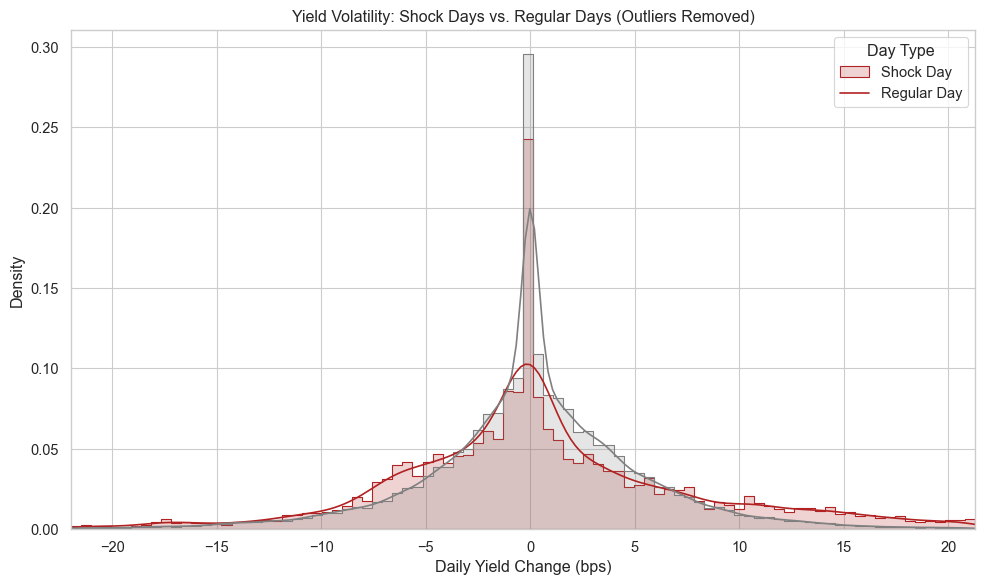

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define Day Type
out['day_type'] = out['OIS_2Y'].apply(lambda x: 'Shock Day' if x != 0 else 'Regular Day')

# 2. Filter Outliers (Keep the middle 99%)
# This removes the "very large or very small" values that distort the plot
low_cutoff = out['delta_y'].quantile(0.005)
high_cutoff = out['delta_y'].quantile(0.995)

plot_data = out[
    (out['delta_y'] > low_cutoff) & 
    (out['delta_y'] < high_cutoff)
].copy()

# 3. Plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

sns.histplot(
    data=plot_data, 
    x='delta_y', 
    hue='day_type',
    palette=['gray', 'firebrick'], 
    stat='density',      # Normalize area to 1
    common_norm=False,   # Calculate density separately for each group
    element='step',      # Clean step-lines
    bins=90,             # Fewer bins often looks cleaner for density comparison
    alpha=0.2,
    kde=True             # Add the smooth line
)

# 4. Labeling
plt.title('Yield Volatility: Shock Days vs. Regular Days (Outliers Removed)')
plt.xlabel('Daily Yield Change (bps)')
plt.ylabel('Density')
plt.legend(title='Day Type', labels=['Shock Day', 'Regular Day'])
plt.xlim(plot_data['delta_y'].min(), plot_data['delta_y'].max()) # Tighten x-axis

plt.tight_layout()
plt.show()

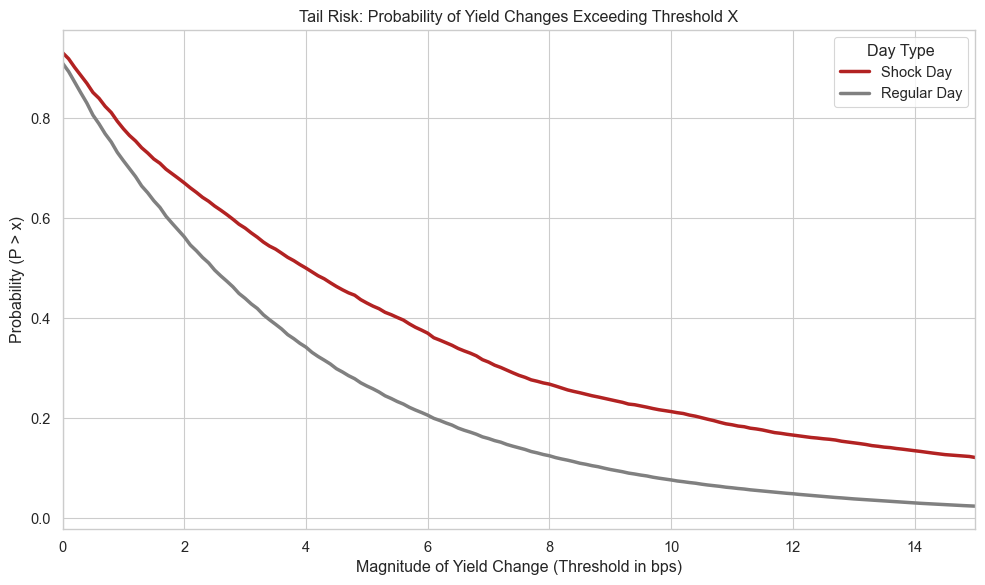

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
# Calculate absolute yield changes to focus on magnitude
out['abs_delta_y'] = out['delta_y'].abs()
out['day_type'] = out['OIS_2Y'].apply(lambda x: 'Shock Day' if x != 0 else 'Regular Day')

# 2. Define a continuous range of thresholds (e.g., 0 to 15 bps)
# We use a fine grid (e.g., every 0.1 bps) to make the line smooth
thresholds = np.linspace(0, 15, 151) 

# 3. Calculate Exceedance Probability for each point
# P(Yield Change > x)
results = []

# Pre-calculate groups for speed
shock_values = out[out['day_type'] == 'Shock Day']['abs_delta_y'].values
regular_values = out[out['day_type'] == 'Regular Day']['abs_delta_y'].values

for t in thresholds:
    # Calculate share of observations greater than t
    prob_shock = np.mean(shock_values > t)
    prob_regular = np.mean(regular_values > t)
    
    results.append({'Threshold': t, 'Day Type': 'Shock Day', 'Probability': prob_shock})
    results.append({'Threshold': t, 'Day Type': 'Regular Day', 'Probability': prob_regular})

df_continuous = pd.DataFrame(results)

# 4. Plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# Lineplot creates the continuous feel
sns.lineplot(
    data=df_continuous, 
    x='Threshold', 
    y='Probability', 
    hue='Day Type',
    palette=['firebrick', 'gray'],
    linewidth=2.5
)

# 5. Formatting
plt.title('Tail Risk: Probability of Yield Changes Exceeding Threshold X')
plt.xlabel('Magnitude of Yield Change (Threshold in bps)')
plt.ylabel('Probability (P > x)')
plt.xlim(0, 15)

# Optional: Log scale helps visualize the "tail" difference if probabilities get very small
# plt.yscale('log') 

plt.tight_layout()
plt.show()

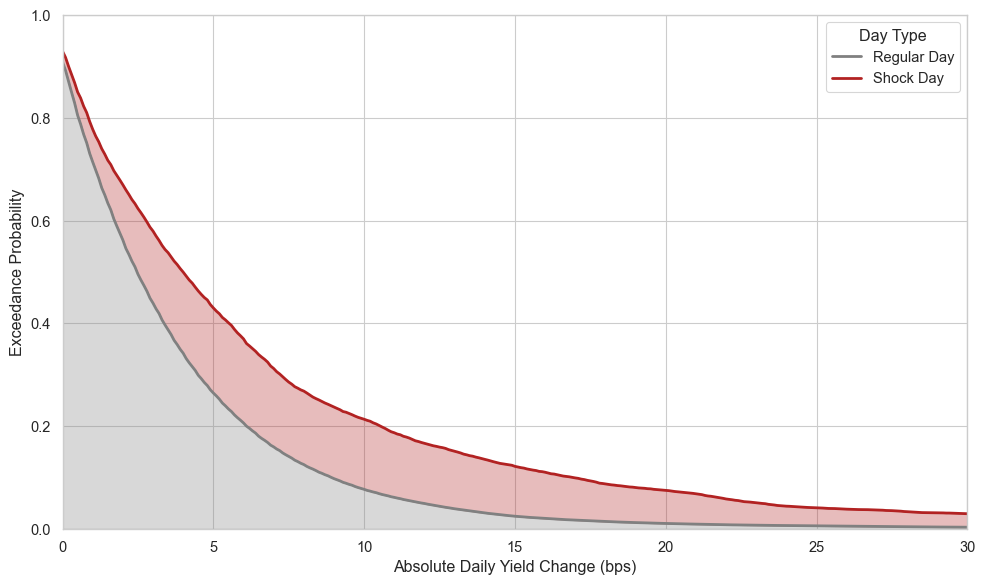

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
out['abs_delta_y'] = out['delta_y'].abs()
out['day_type'] = out['OIS_2Y'].apply(lambda x: 'Shock Day' if x != 0 else 'Regular Day')

# 2. Define Continuous Thresholds
thresholds = np.linspace(0, 30, 301)

# 3. Calculate Exceedance Probabilities
results = []
shock_values = out[out['day_type'] == 'Shock Day']['abs_delta_y'].values
regular_values = out[out['day_type'] == 'Regular Day']['abs_delta_y'].values

for t in thresholds:
    results.append({
        'Threshold': t, 
        'Shock Day': np.mean(shock_values > t), 
        'Regular Day': np.mean(regular_values > t)
    })

df_plot = pd.DataFrame(results)

# 4. Plot
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(10, 6))

# A. Base Risk (Regular Days)
# We plot the Gray line and fill everything below it as "Standard Market Risk"
plt.plot(df_plot['Threshold'], df_plot['Regular Day'], 
         color='gray', label='Regular Day', linewidth=2)
plt.fill_between(df_plot['Threshold'], 0, df_plot['Regular Day'], 
                 color='gray', alpha=0.3)

# B. Excess Risk (Shock Days)
# We plot the Red line, but we ONLY fill the area BETWEEN Gray and Red.
# This visually isolates the "Marginal Contribution" of the shock.
plt.plot(df_plot['Threshold'], df_plot['Shock Day'], 
         color='firebrick', label='Shock Day', linewidth=2)

plt.fill_between(df_plot['Threshold'], df_plot['Regular Day'], df_plot['Shock Day'],
                 where=(df_plot['Shock Day'] >= df_plot['Regular Day']),
                 color='firebrick', alpha=0.3, interpolate=True)

# 5. Formatting
plt.xlabel('Absolute Daily Yield Change (bps)')
plt.ylabel('Exceedance Probability')
plt.xlim(0, 30)
plt.ylim(0, 1)
plt.legend(title='Day Type')

plt.tight_layout()
plt.show()

## Desc graph

In [ ]:
# Data prep
query = f""" 

SELECT s.business_date, 
security_isin as isin,
sum(nominal_euro) as borrowing_volume

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND (
(security_type = 'GOVS' AND LEFT(security_isin, 2) IN ('DE', 'IT', 'FR', 'ES') AND gnlcoll = 'SPEC' AND assttp_scty_issr_sector_riad = 'S1311') 
OR (LEFT(security_isin, 2) IN ('DE', 'IT', 'FR', 'ES') AND gnlcoll = 'SPEC' AND security_isin IN {unique_govs})) --EA GOVS) 
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_23336\3467913139.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [ ]:
# Data prep
query = f""" 
 

SELECT s.business_date,
security_isin as isin,
sum(nominal_euro) as lending_volume

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND (
(security_type = 'GOVS' AND LEFT(security_isin, 2) IN ('DE', 'IT', 'FR', 'ES') AND gnlcoll = 'SPEC' AND assttp_scty_issr_sector_riad = 'S1311') 
OR (LEFT(security_isin, 2) IN ('DE', 'IT', 'FR', 'ES') AND gnlcoll = 'SPEC' AND security_isin IN {unique_govs})) --EA GOVS) 
GROUP BY business_date, isin
ORDER BY business_date, isin 

""" 

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_23336\1002733318.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [ ]:
df_repo = df_borrowing.merge( df_lending, on=['business_date', 'isin'], how='outer', suffixes=('_borrowing', '_lending') )
 

In [ ]:
df_repo = df_borrowing.merge( df_lending, on=['business_date', 'isin'], how='outer', suffixes=('_borrowing', '_lending') )
 

In [ ]:
df_repo['borrowing_volume'].fillna(0, inplace = True)
df_repo['lending_volume'].fillna(0, inplace = True)

In [ ]:
df_repo['net_pos'] = (df_repo['borrowing_volume'] - df_repo['lending_volume'])/1e9

In [ ]:
df_repo['net_pos'].fillna(0, inplace=True)

In [ ]:
df_repo['business_date'] = pd.to_datetime(df_repo['business_date'])

In [ ]:
df_repo['collateral_country'] = df_repo['isin'].str[:2]

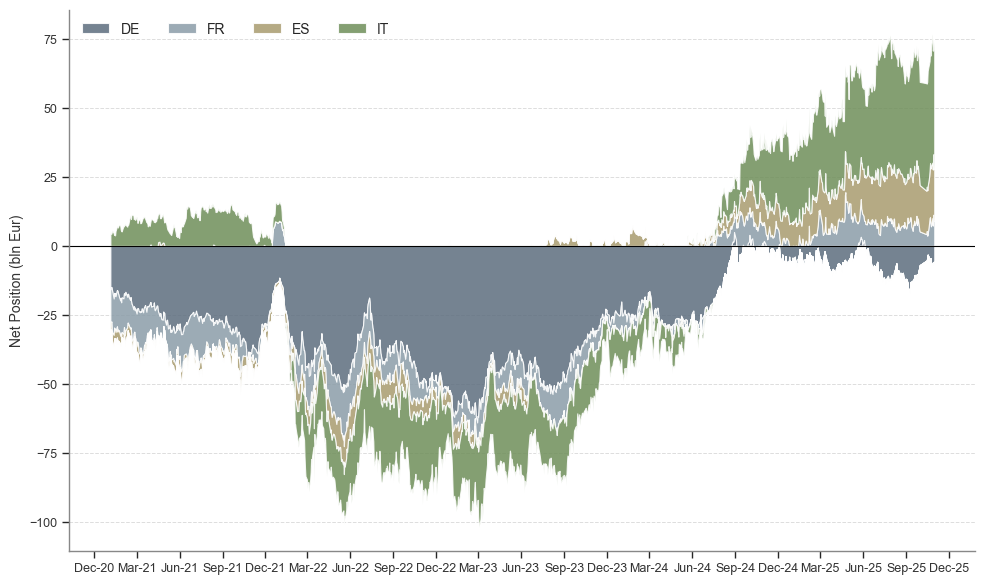

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. PREPARE THE DATA
df_repo['business_date'] = pd.to_datetime(df_repo['business_date'])

# Expand to all four countries
target_countries = ['DE', 'IT', 'ES', 'FR']
df_filtered = df_repo[df_repo['collateral_country'].isin(target_countries)].copy()

# Pivot the data
df_pivot = df_filtered.pivot_table(
    index='business_date', 
    columns='collateral_country', 
    values='net_pos', 
    aggfunc='sum'
).fillna(0)

# Reorder columns from core to periphery for consistent visual layering
col_order = [c for c in ['DE', 'FR', 'ES', 'IT'] if c in df_pivot.columns]
df_pivot = df_pivot[col_order]

# Separate positive and negative flows
df_pos = df_pivot.clip(lower=0)
df_neg = df_pivot.clip(upper=0)

# 2. AESTHETICS
colors_map = {
    'DE': '#5D6D7E',  # Slate grey (core)
    'FR': '#8B9DA8',  # Lighter grey-blue (semi-core)
    'ES': '#A89B6E',  # Muted gold (periphery)
    'IT': '#6E8E59'   # Muted olive green (periphery)
}
cols_in_plot = df_pivot.columns
plot_colors = [colors_map.get(c, '#888888') for c in cols_in_plot]

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# 3. PLOT
fig, ax = plt.subplots(figsize=(10, 6))

ax.stackplot(df_pos.index, df_pos.T, labels=cols_in_plot, colors=plot_colors, alpha=0.85)
ax.stackplot(df_neg.index, df_neg.T, colors=plot_colors, alpha=0.85)

# 4. FORMATTING
ax.set_ylabel('Net Position (bln Eur)', fontsize=10, color='#333333')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

ax.grid(axis='y', color='#DDDDDD', linestyle='--', linewidth=0.7, zorder=0)
ax.axhline(0, color='black', linewidth=0.8, zorder=1)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
plt.xticks(rotation=0, fontsize=9, color='#333333')
plt.yticks(fontsize=9, color='#333333')

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), 
          frameon=False, loc='upper left', ncol=4, fontsize=10)

plt.tight_layout()
plt.show()

# External validity

In [ ]:
# Data prep
query = f""" 

SELECT business_date, sum(nominal_euro) as borrowing_volume, LEFT(security_isin, 2) as cntr

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01' 
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND borrower_country_residence = 'KY' AND s_borrower.sector = 'IF'
AND (
(security_type = 'GOVS' AND LEFT(security_isin, 2) IN ('AT','BE','CY','DE','EE','ES','FI','FR','GR','IE','IT', 'LT','LU','LV','MT','NL','PT','SI','SK','HR') AND gnlcoll = 'SPEC' AND assttp_scty_issr_sector_riad = 'S1311') 
OR (LEFT(security_isin, 2) IN ('AT','BE','CY','DE','EE','ES','FI','FR','GR','IE','IT', 'LT','LU','LV','MT','NL','PT','SI','SK','HR') AND gnlcoll = 'SPEC' AND security_isin IN {unique_govs})) --EA GOVS) 
--AND contractual_maturity <= 1
GROUP BY business_date, cntr

""" 

df_borrowing = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_23336\1753255612.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_borrowing = pd.read_sql_query(query, cnxn)


In [ ]:
# Data prep
query = f""" 
 

SELECT 
business_date, sum(nominal_euro) as lending_volume, LEFT(security_isin, 2) as cntr

FROM xlab_ecb_prj_sftds_cb_common.hermesf_state_backup s 
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_borrower ON s.borrower_id = s_borrower.id
LEFT JOIN lab_prj_emir_ecb.mbf_sector_enrichment_20210531 s_lender ON s.lender_id = s_lender.id
WHERE s.business_date >= '2021-01-04' AND s.business_date <= '2025-11-01'  
AND nominal_ccy IN ('EUR') 
AND central_clearing = 'non-cleared' 
AND lender_country_residence = 'KY' AND s_lender.sector = 'IF'
AND (
(security_type = 'GOVS' AND LEFT(security_isin, 2) IN ('AT','BE','CY','DE','EE','ES','FI','FR','GR','IE','IT', 'LT','LU','LV','MT','NL','PT','SI','SK','HR') AND gnlcoll = 'SPEC' AND assttp_scty_issr_sector_riad = 'S1311') 
OR (LEFT(security_isin, 2) IN ('AT','BE','CY','DE','EE','ES','FI','FR','GR','IE','IT', 'LT','LU','LV','MT','NL','PT','SI','SK','HR') AND gnlcoll = 'SPEC' AND security_isin IN {unique_govs})) --EA GOVS) 
--AND contractual_maturity <= 1
GROUP BY business_date, cntr

""" 

df_lending = pd.read_sql_query(query, cnxn)

C:\Users\hermesf\AppData\Local\Temp\ipykernel_23336\3732770950.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_lending = pd.read_sql_query(query, cnxn)


In [ ]:
df_repo = df_borrowing.merge( df_lending, on=['business_date','cntr'], how='outer', suffixes=('_borrowing', '_lending') )
 

In [ ]:
df_repo['borrowing_volume'].fillna(0, inplace = True)
df_repo['lending_volume'].fillna(0, inplace = True)

In [ ]:
df_repo['gross_position'] = (df_repo['borrowing_volume'] - df_repo['lending_volume']).abs()

In [ ]:
df_repo.head()

,business_date,borrowing_volume,cntr,lending_volume,gross_position
0,2022-11-15,3.050439e+10,DE,8.145085e+10,5.094645e+10
1,2021-03-22,1.662600e+07,SK,2.686494e+07,1.023894e+07
2,2021-03-05,1.474667e+10,ES,1.809005e+10,3.343378e+09
3,2021-02-22,1.573561e+09,AT,8.845998e+08,6.889612e+08
4,2021-04-30,3.381824e+07,SK,5.999736e+06,2.781850e+07


In [ ]:
df_repo = df_repo[['cntr', 'gross_position']].groupby('cntr').mean().reset_index()

In [ ]:
df_repo

,cntr,gross_position
0,AT,8.451408e+08
1,BE,1.449082e+09
2,DE,2.727466e+10
3,ES,6.011354e+09
4,FI,1.135754e+09
5,FR,7.570996e+09
6,GR,1.010985e+09
7,IE,5.646286e+08
8,IT,1.844195e+10
9,LU,1.724496e+07


In [ ]:
df_repo['share'] = (df_repo['gross_position']/df_repo['gross_position'].sum()) * 100

In [ ]:
df_repo

In [ ]:
df_repo.sort_values(by='share', ascending=False)

,cntr,gross_position,share
2,DE,2.727466e+10,40.923959
8,IT,1.844195e+10,27.671022
5,FR,7.570996e+09,11.359818
3,ES,6.011354e+09,9.019670
10,NL,1.540903e+09,2.312031
1,BE,1.449082e+09,2.174259
4,FI,1.135754e+09,1.704130
6,GR,1.010985e+09,1.516921
0,AT,8.451408e+08,1.268082
11,PT,6.458204e+08,0.969014
